In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
from IPython.display import display
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.svm import SVC


%load_ext autoreload
%autoreload 2
import importlib
import sys
sys.path.append("../src/")
import modele
importlib.reload(modele)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<module 'modele' from 'c:\\Users\\anton\\Downloads\\A3\\analyse données\\Winunmax\\notebooks\\../src\\modele.py'>

In [89]:
df = pd.read_csv("../data/preparee/dataframe_traite.csv")
#Je laisse game_id pour le moment pour des vérifications
X = df.drop(columns=["game_id","home_club_name","away_club_name","date","season","home_club_id","away_club_id","results","difference classement","home_club_position","away_club_position"]) 
Y = df["results"]
display(X.head(3))
display("classes déséquilibrée ",Y.value_counts())
display(X.info())

X_train_avec_2012, X_temp_avec_2012, Y_train_avec_2012, Y_temp_avec_2012 = train_test_split(X, Y, test_size=0.3, random_state=42)
X_validation_avec_2012, X_test_avec_2012, Y_validation_avec_2012, Y_test_avec_2012 = train_test_split(X_temp_avec_2012, Y_temp_avec_2012, test_size=0.5, random_state=42)

,Difference value home et away,Ratio value home par away,LOG Ratio value home par away,winrate_home 1 ans,winrate_away 1 ans,difference winrate home-away 1 ans,winrate_home 2 ans,winrate_away 2 ans,difference winrate home-away 2 ans,winrate_home 3 ans,...,difference de buts moyenne home-away 2 ans,diffbut_moy_home_3_ans,diffbut_moy_away_3_ans,difference de buts moyenne home-away 3 ans,evolution difference de buts home 3 et 1 ans,evolution difference de buts away 3 et 1 ans,evolution difference de buts entre équipes entre 3 et 1 ans,diffbut_moy_confrontation_1_ans,diffbut_moy_confrontation_2_ans,diffbut_moy_confrontation_3_ans
0,17500000.0,2.206897,0.791587,0.618421,0.447368,0.171053,0.618421,0.447368,0.171053,0.618421,...,1.157895,0.736842,-0.421053,1.157895,0.0,0.0,0.0,3.0,3.0,3.0
1,-500000.0,0.928058,-0.074662,0.394737,0.350000,0.044737,0.394737,0.350000,0.044737,0.394737,...,-0.184211,-0.184211,0.000000,-0.184211,0.0,0.0,0.0,0.0,0.0,0.0
2,-18200000.0,0.257143,-1.358123,0.473684,0.605263,-0.131579,0.473684,0.605263,-0.131579,0.473684,...,-0.605263,-0.105263,0.500000,-0.605263,0.0,0.0,0.0,-1.5,-1.5,-1.5


'classes déséquilibrée '

results
 1    1802
-1    1203
 0    1073
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4078 entries, 0 to 4077
Data columns (total 47 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Difference value home et away                                   4078 non-null   float64
 1   Ratio value home par away                                       4078 non-null   float64
 2   LOG Ratio value home par away                                   4078 non-null   float64
 3   winrate_home 1 ans                                              4078 non-null   float64
 4   winrate_away 1 ans                                              4078 non-null   float64
 5   difference winrate home-away 1 ans                              4078 non-null   float64
 6   winrate_home 2 ans                                              4078 non-null   float64
 7   winrate_away 2 ans                                 

None

In [57]:
mi = mutual_info_classif(X, Y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(mi_series)

difference de buts moyenne home-away 2 ans                        0.058161
difference winrate home-away 3 ans                                0.056027
pos_moy_away_1_ans                                                0.055696
difference de buts moyenne home-away 3 ans                        0.054871
difference winrate home-away 1 ans                                0.052769
difference de buts moyenne home-away 1 ans                        0.051365
diffbut_moy_home_2_ans                                            0.049049
pos_moy_home_1_ans                                                0.042548
winrate_home 3 ans                                                0.041519
pos_moy_away_3_ans                                                0.041386
LOG Ratio value home par away                                     0.041208
diffbut_moy_away_1_ans                                            0.040493
winrate_away 2 ans                                                0.040297
Ratio value home par away

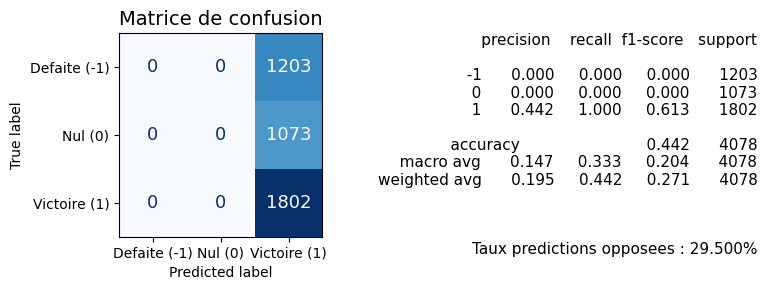

In [58]:
#Modèle 1 de référence (NAIF)

y_1_pred = pd.Series([1]*len(X))

modele.affichage_complet_score(Y,y_1_pred)

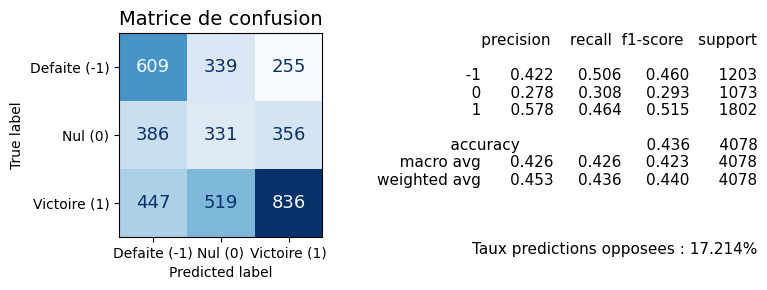

In [59]:
#Modèle 2 de référence

y_2_pred = modele.prediction_modele_simple_diff_winrate(X["difference winrate home-away 1 ans"])

modele.affichage_complet_score(Y,y_2_pred)

In [60]:
df_sans_2012 = pd.read_csv("../data/preparee/dataframe_traite_sans_2012.csv")

X_sans_2012 = df_sans_2012.drop(columns=["game_id","home_club_name","away_club_name","date","season","home_club_id","away_club_id","results","difference classement","home_club_position","away_club_position"]) 
Y_sans_2012 = df_sans_2012["results"]



In [61]:
mi_sans_2012 = mutual_info_classif(X_sans_2012, Y_sans_2012, random_state=42)
mi_series_sans_2012 = pd.Series(mi_sans_2012, index=X_sans_2012.columns).sort_values(ascending=False)
print("On remarque que les features sont plus informatives et que les features qui se basent sur" \
" l’historique apparaissent \nplus importantes (6/6 premiers, alors que 4/6 en incluant 2012), or on utilisera pour prédire 2023 des features historiques uniquement\n")
print(mi_series_sans_2012)

On remarque que les features sont plus informatives et que les features qui se basent sur l’historique apparaissent 
plus importantes (6/6 premiers, alors que 4/6 en incluant 2012), or on utilisera pour prédire 2023 des features historiques uniquement

difference winrate home-away 3 ans                                0.063711
difference de buts moyenne home-away 2 ans                        0.062173
difference de buts moyenne home-away 3 ans                        0.059886
pos_moy_home_2_ans                                                0.057443
difference de buts moyenne home-away 1 ans                        0.054300
diffbut_moy_home_2_ans                                            0.052724
pos_moy_away_1_ans                                                0.050309
winrate_home 3 ans                                                0.049147
pos_moy_away_2_ans                                                0.048603
difference winrate home-away 1 ans                                0.0484

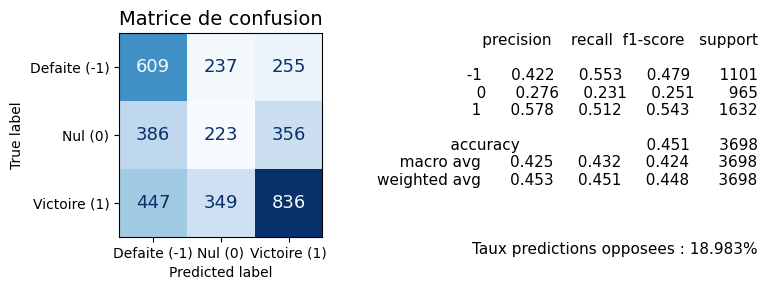


Accuracy meilleure de 1.6 points et F1 score meilleur de 0.2 points, on peut supposer que c’est meilleur mais à vérifier car possiblement du bruit


In [62]:
#Modèle 2 de référence

y_2_pred_sans_2012 = modele.prediction_modele_simple_diff_winrate(X_sans_2012["difference winrate home-away 1 ans"])

modele.affichage_complet_score(Y_sans_2012,y_2_pred_sans_2012)

print("\nAccuracy meilleure de 1.6 points et F1 score meilleur de 0.2 points, on peut supposer que c’est meilleur mais à vérifier car possiblement du bruit")

In [63]:
X_train_sans_2012, X_temp_sans_2012, Y_train_sans_2012, Y_temp_sans_2012 = train_test_split(X_sans_2012, Y_sans_2012, test_size=0.3, random_state=42)
X_validation_sans_2012, X_test_sans_2012, Y_validation_sans_2012, Y_test_sans_2012 = train_test_split(X_temp_sans_2012, Y_temp_sans_2012, test_size=0.5, random_state=42)

SVM

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sans_2012_scaled = scaler.fit_transform(X_train_sans_2012)
X_validation_sans_2012_scaled = scaler.fit_transform(X_validation_sans_2012)

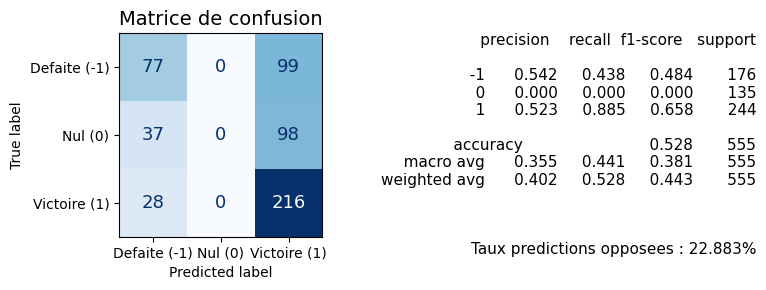

In [65]:
svm_model = SVC(kernel="linear")
svm_model.fit(X_train_sans_2012_scaled, Y_train_sans_2012)
y_svm_prediction_validation_1 = svm_model.predict(X_validation_sans_2012_scaled)
modele.affichage_complet_score(Y_validation_sans_2012,y_svm_prediction_validation_1)

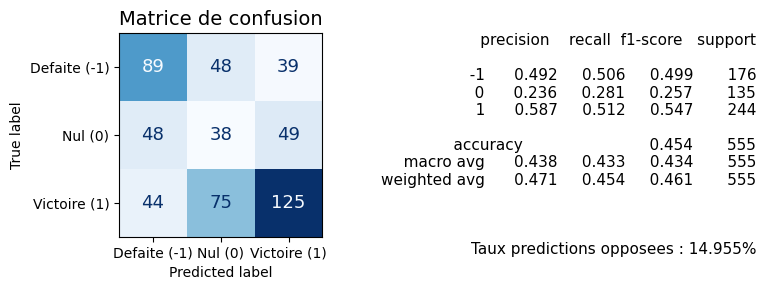

In [66]:
svm_model = SVC(kernel="linear",class_weight="balanced")
svm_model.fit(X_train_sans_2012_scaled, Y_train_sans_2012)
y_svm_prediction_validation_1 = svm_model.predict(X_validation_sans_2012_scaled)
modele.affichage_complet_score(Y_validation_sans_2012,y_svm_prediction_validation_1)

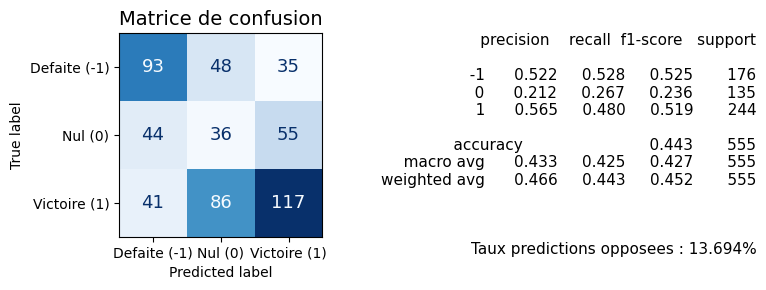

In [67]:
svm_model = SVC(kernel="rbf",class_weight="balanced")
svm_model.fit(X_train_sans_2012_scaled, Y_train_sans_2012)
y_svm_prediction_validation_1 = svm_model.predict(X_validation_sans_2012_scaled)
modele.affichage_complet_score(Y_validation_sans_2012,y_svm_prediction_validation_1)

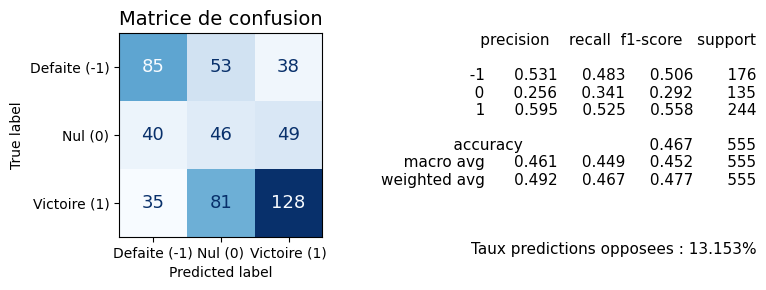

In [68]:
svm_model = SVC(kernel="rbf",class_weight="balanced",gamma="scale",C=0.1)
svm_model.fit(X_train_sans_2012_scaled, Y_train_sans_2012)
y_svm_prediction_validation_1 = svm_model.predict(X_validation_sans_2012_scaled)
modele.affichage_complet_score(Y_validation_sans_2012,y_svm_prediction_validation_1)

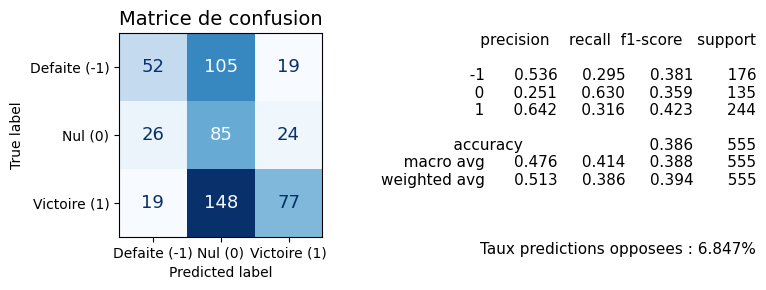

In [69]:
svm_model = SVC(kernel="poly",class_weight="balanced")
svm_model.fit(X_train_sans_2012_scaled, Y_train_sans_2012)
y_svm_prediction_validation_1 = svm_model.predict(X_validation_sans_2012_scaled)
modele.affichage_complet_score(Y_validation_sans_2012,y_svm_prediction_validation_1)

In [70]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Exemple : pipeline avec standardisation + SVM
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# Grille des hyperparamètres à tester
param_grid = {
    'svm__C': [0.01, 0.1, 1],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['rbf', 'linear'],
    'svm__class_weight': [None, 'balanced']
}

# Recherche par validation croisée
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)

# Entraînement
grid_search.fit(X_train_sans_2012, Y_train_sans_2012)

# Meilleurs paramètres
print("Meilleurs hyperparamètres :", grid_search.best_params_)

# Meilleur score
print("Meilleur score (f1_macro) :", grid_search.best_score_)


Meilleurs hyperparamètres : {'svm__C': 0.1, 'svm__class_weight': 'balanced', 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Meilleur score (f1_macro) : 0.42978756674000385


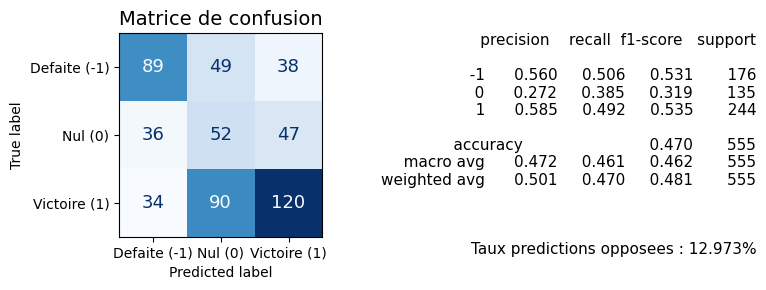

In [71]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# 1. Définir le nombre de composantes (par exemple, 95% de variance expliquée)
pca = PCA(n_components=0.97)  # Garde assez de composantes pour expliquer 95% de la variance

# 2. Définir le modèle SVM
svm = SVC(kernel="linear",class_weight="balanced")

# 3. Pipeline PCA + SVM
pipeline = Pipeline([
    ('pca', pca),
    ('svm', svm)
])

# 4. Entraînement sur données réduites
pipeline.fit(X_train_sans_2012_scaled, Y_train_sans_2012)

# 5. Prédiction sur jeu de validation réduit
y_pred_validation = pipeline.predict(X_validation_sans_2012_scaled)

# 6. Évaluation avec ta fonction
modele.affichage_complet_score(Y_validation_sans_2012,y_pred_validation)


ARBRE DÉCISION

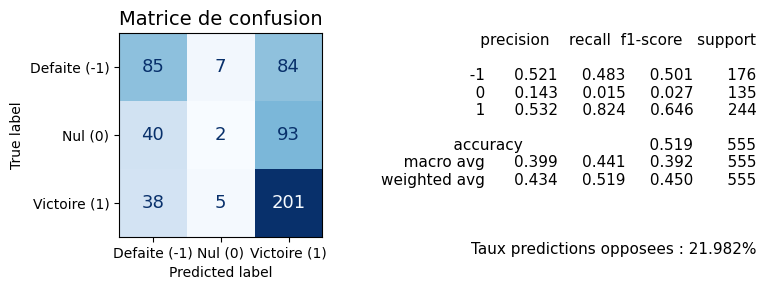

In [72]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    criterion="entropy",         # ou "entropy"
    max_depth=5,              # profondeur maximale de l'arbre
    min_samples_split=20,     # min. d'échantillons pour un split
    min_samples_leaf=4,       # min. d'échantillons dans une feuille
    random_state=42)
tree_model.fit(X_train_sans_2012, Y_train_sans_2012)

# Prédiction
y_pred_tree = tree_model.predict(X_validation_sans_2012)




# Transformation en DataFrame avec les bons index
#y_pred_tree_df = pd.DataFrame(y_pred_tree, index=Y_validation_sans_2012.index, columns=["prediction"])

modele.affichage_complet_score(Y_validation_sans_2012,y_pred_tree)

In [73]:
from sklearn.tree import export_text

arbre_texte = export_text(tree_model, feature_names=list(X_train_sans_2012.columns))
print(arbre_texte)

|--- difference winrate home-away 3 ans <= -0.00
|   |--- Ratio value home par away <= 0.26
|   |   |--- difference de buts moyenne home-away 2 ans <= -1.67
|   |   |   |--- difference winrate home-away 1 ans <= -0.43
|   |   |   |   |--- class: -1
|   |   |   |--- difference winrate home-away 1 ans >  -0.43
|   |   |   |   |--- diffbut_moy_home_1_ans <= -0.45
|   |   |   |   |   |--- class: -1
|   |   |   |   |--- diffbut_moy_home_1_ans >  -0.45
|   |   |   |   |   |--- class: -1
|   |   |--- difference de buts moyenne home-away 2 ans >  -1.67
|   |   |   |--- difference classement moyen home-away 3 ans <= 16.18
|   |   |   |   |--- difference winrate home-away 3 ans <= -0.06
|   |   |   |   |   |--- class: -1
|   |   |   |   |--- difference winrate home-away 3 ans >  -0.06
|   |   |   |   |   |--- class: 0
|   |   |   |--- difference classement moyen home-away 3 ans >  16.18
|   |   |   |   |--- class: -1
|   |--- Ratio value home par away >  0.26
|   |   |--- difference de buts moye

In [74]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 1. Définir le modèle de base
tree = DecisionTreeClassifier(random_state=42)

# 2. Grille de paramètres à tester
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2,3,4, 5,6,7,8, 9,10,13, None],
    'min_samples_split': [3,4,5,10,20],
    'min_samples_leaf': [5,6,8,9,10]
}

# 3. Définir GridSearchCV
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='f1_weighted',     # ou 'f1_weighted', 'precision_macro' etc.
    n_jobs=-1,               # Utiliser tous les cœurs CPU
    verbose=1
)

# 4. Lancer la recherche
grid_search.fit(X_train_sans_2012, Y_train_sans_2012)
print(X_train_sans_2012.shape)

# 5. Résultats
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score cross-val :", grid_search.best_score_)

# 6. Utiliser le meilleur modèle
best_tree = grid_search.best_estimator_

Fitting 5 folds for each of 550 candidates, totalling 2750 fits
(2588, 47)
Meilleurs paramètres : {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 6, 'min_samples_split': 3}
Meilleur score cross-val : 0.44049395325488944


RANDOM FOREST

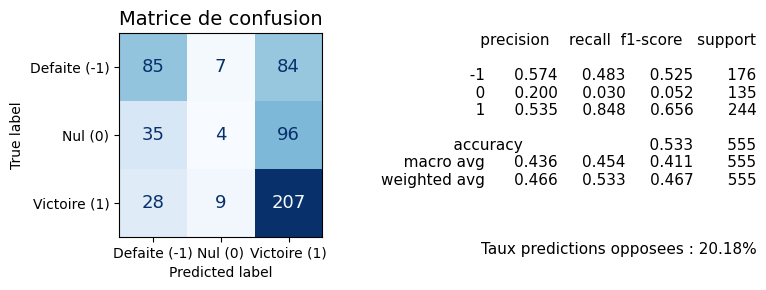

In [75]:
from sklearn.ensemble import RandomForestClassifier
#classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)

rf_classifier = RandomForestClassifier(criterion='gini', 
                             n_estimators=2000,
                             min_samples_split=50,
                             min_samples_leaf=3,
                             max_features='sqrt',
                             oob_score=True,
                             random_state=1,
                             n_jobs=-1)
rf_classifier.fit(X_train_sans_2012, Y_train_sans_2012)

y_pred_tree = rf_classifier.predict(X_validation_sans_2012)
modele.affichage_complet_score(Y_validation_sans_2012,y_pred_tree)

XGBoost

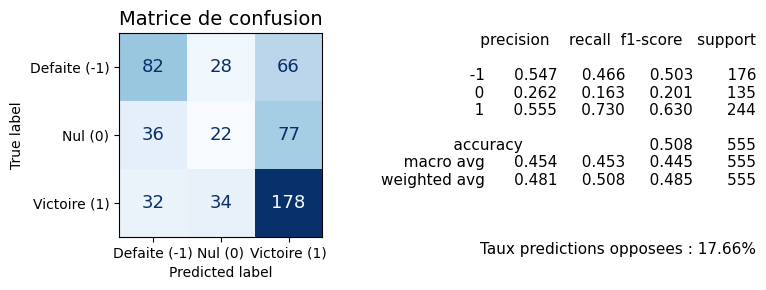

In [76]:
from xgboost import XGBClassifier
classifier = XGBClassifier(n_estimators=500, max_depth=3,booster="gbtree",subsample=0.2,colsample_bytree=0.2,reg_alpha=0.1, learning_rate=0.1,objective='multi:softmax', random_state=42,min_child_weight=5)
classifier.fit(X_train_sans_2012, Y_train_sans_2012+1)
y_pred_xgboost = classifier.predict(X_validation_sans_2012)

modele.affichage_complet_score(Y_validation_sans_2012,y_pred_xgboost-1)

0:	learn: 1.0905002	total: 21.1ms	remaining: 10.6s
100:	learn: 0.9726559	total: 416ms	remaining: 1.64s
200:	learn: 0.9343080	total: 867ms	remaining: 1.29s
300:	learn: 0.8969817	total: 1.28s	remaining: 844ms
400:	learn: 0.8641269	total: 1.66s	remaining: 409ms
499:	learn: 0.8333257	total: 2.08s	remaining: 0us


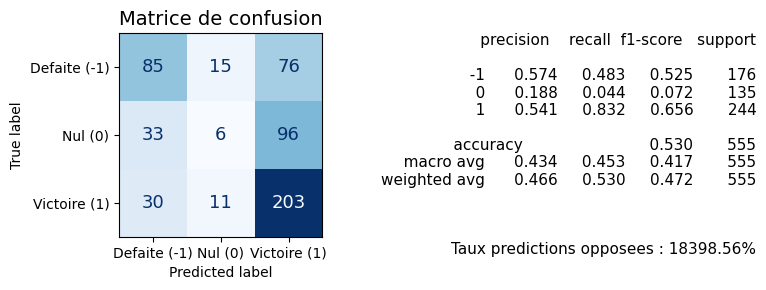

In [77]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    loss_function='MultiClass',
    eval_metric='MultiClass',
    custom_metric=["F1"],
    cat_features = ["nouveau club home 3 ans","nouveau club home 1 ans","nouveau club away 3 ans","nouveau club away 1 ans"],
    verbose=100,
    early_stopping_rounds=100,
    random_state=42
)

model.fit(X_train_sans_2012,Y_train_sans_2012)
y_pred_cat = model.predict(X_validation_sans_2012)

modele.affichage_complet_score(Y_validation_sans_2012,y_pred_cat)

RÉGRESSION LOGISTIQUE

c:\Users\anton\Downloads\A3\analyse données\Winunmax\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


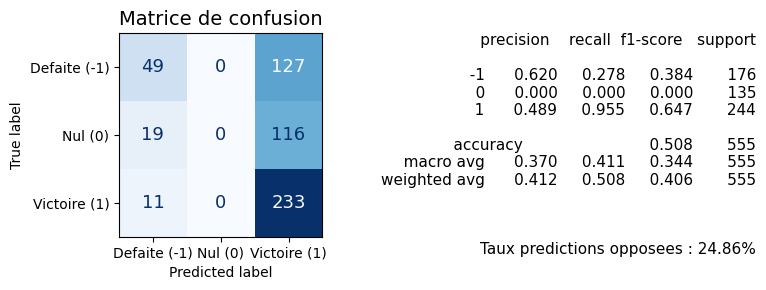

In [78]:
from sklearn.linear_model import LogisticRegression

lr_classifier = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)

lr_classifier.fit(X_train_sans_2012,Y_train_sans_2012)

y_pred_lr = lr_classifier.predict(X_validation_sans_2012)

modele.affichage_complet_score(Y_validation_sans_2012,y_pred_lr)

c:\Users\anton\Downloads\A3\analyse données\Winunmax\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


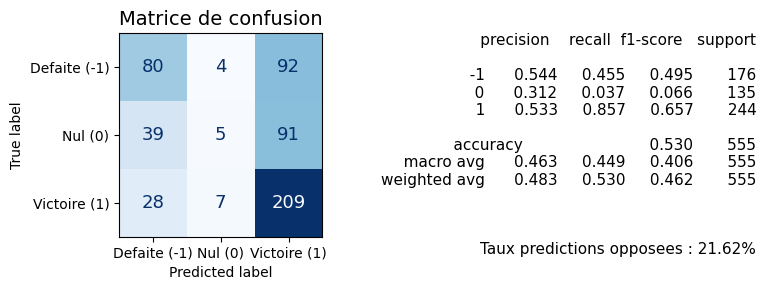

In [79]:
lr_classifier = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)

lr_classifier.fit(X_train_sans_2012_scaled,Y_train_sans_2012)

y_pred_lr = lr_classifier.predict(X_validation_sans_2012_scaled)

modele.affichage_complet_score(Y_validation_sans_2012,y_pred_lr)

c:\Users\anton\Downloads\A3\analyse données\Winunmax\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


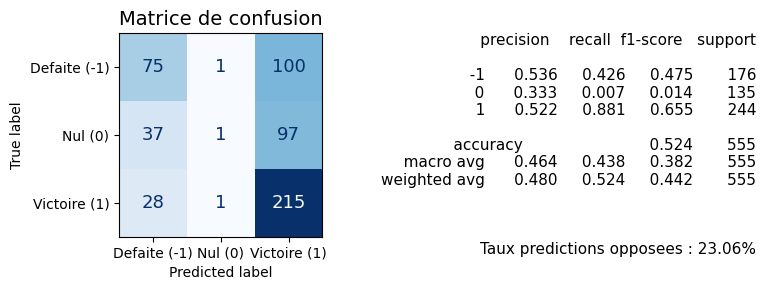

In [80]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# 1. Définir le nombre de composantes (par exemple, 95% de variance expliquée)
pca = PCA(n_components=0.97)  # Garde assez de composantes pour expliquer 95% de la variance

lr_classifier = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)


# 3. Pipeline PCA + SVM
pipeline = Pipeline([
    ('pca', pca),
    ('lr', lr_classifier)
])

# 4. Entraînement sur données réduites
pipeline.fit(X_train_sans_2012_scaled, Y_train_sans_2012)

# 5. Prédiction sur jeu de validation réduit
y_pred_validation = pipeline.predict(X_validation_sans_2012_scaled)

# 6. Évaluation avec ta fonction
modele.affichage_complet_score(Y_validation_sans_2012,y_pred_validation)

RÉGRESSION
 (Les classes prédites (-1,0,1) ont un sens et sont ordonnées, on peut donc essayer de la régression classique)

Régression ordinale

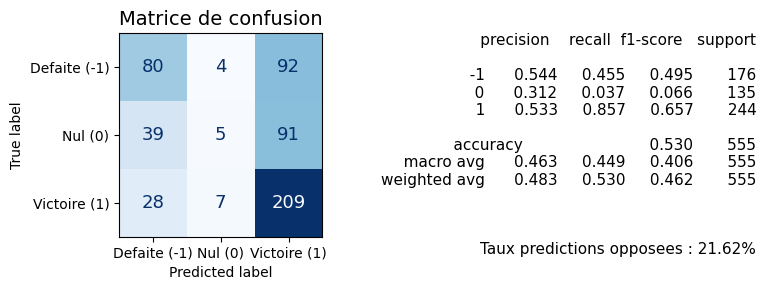

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report

# Encoder ordinale si y est sous forme de chaînes (ici déjà numérique)
y_train_enc = Y_train_sans_2012 + 1  # Pour passer de [-1,0,1] à [0,1,2]
y_validation_enc = Y_validation_sans_2012 + 1

clf_ord = LogisticRegression(max_iter=1000, solver='lbfgs')
clf_ord.fit(X_train_sans_2012_scaled, y_train_enc)

y_pred_ord = clf_ord.predict(X_validation_sans_2012_scaled) - 1  # On remet dans l'échelle [-1,0,1]
modele.affichage_complet_score(Y_validation_sans_2012,y_pred_ord)


Régression linéaire avec seuil

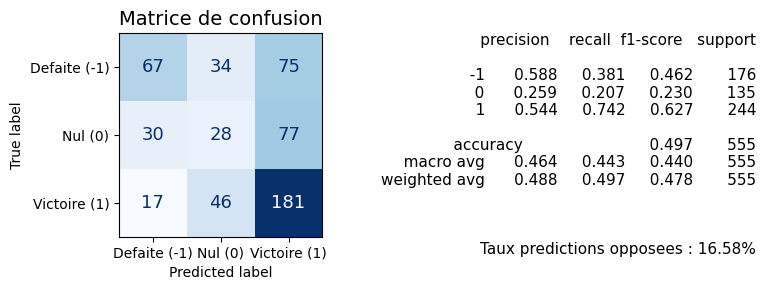

In [82]:
from sklearn.linear_model import LinearRegression

reg_lin = LinearRegression()
reg_lin.fit(X_train_sans_2012_scaled, Y_train_sans_2012)
y_pred_reg = reg_lin.predict(X_validation_sans_2012_scaled)

# Seuils à -0.5 et 0.5 pour classer en -1 / 0 / 1
y_pred_lin = np.where(y_pred_reg < -0.08, -1, np.where(y_pred_reg > 0.08, 1, 0))

modele.affichage_complet_score(Y_validation_sans_2012,y_pred_lin)


Forêt avec seuil

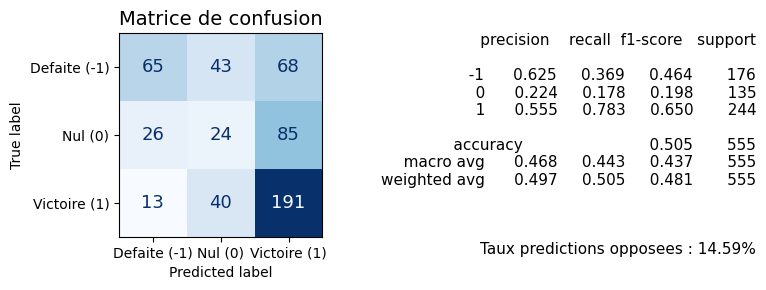

In [83]:
from sklearn.ensemble import RandomForestRegressor

reg_forest = RandomForestRegressor(
    n_estimators=1000,
    min_samples_split=0.09,  #Utiliser du % c’est mieux pour généraliser
    min_samples_leaf=0.006,
    max_features='sqrt',
    oob_score=True,
    random_state=1,
    n_jobs=-1)

reg_forest.fit(X_train_sans_2012, Y_train_sans_2012)
y_pred_forest = reg_forest.predict(X_validation_sans_2012)

# Seuils identiques
y_pred_rf = np.where(y_pred_forest < -0.1, -1, np.where(y_pred_forest > 0.1, 1, 0))

modele.affichage_complet_score(Y_validation_sans_2012, y_pred_rf)

Essai prédiction de 2022

In [84]:
df_2013_2022 = pd.read_csv("../data/preparee/dataframe_traite_sans_2012.csv")

df_temp_1 = df_2013_2022[df_2013_2022["season"]!=2022]
df_temp_2 = df_2013_2022[df_2013_2022["season"]==2022]
X_2013_2021 = df_temp_1.drop(columns=["game_id","home_club_name","away_club_name","date","season","home_club_id","away_club_id","results","difference classement","home_club_position","away_club_position"]) 
X_2022 = df_temp_2.drop(columns=["game_id","home_club_name","away_club_name","date","season","home_club_id","away_club_id","results","difference classement","home_club_position","away_club_position"]) 
Y_2013_2021 = df_temp_1["results"]
Y_2022 = df_temp_2["results"]

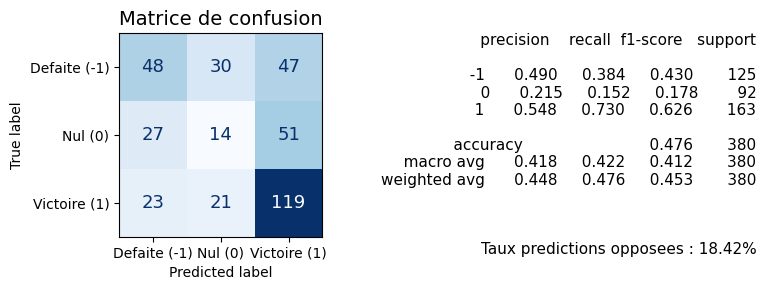

In [85]:
from xgboost import XGBClassifier
classifier = XGBClassifier(n_estimators=500, max_depth=3,booster="gbtree",subsample=0.2,colsample_bytree=0.2,reg_alpha=0.1, learning_rate=0.1,objective='multi:softmax', random_state=42,min_child_weight=5)
classifier.fit(X_2013_2021, Y_2013_2021+1)
y_pred_xgboost = classifier.predict(X_2022)

modele.affichage_complet_score(Y_2022,y_pred_xgboost-1)

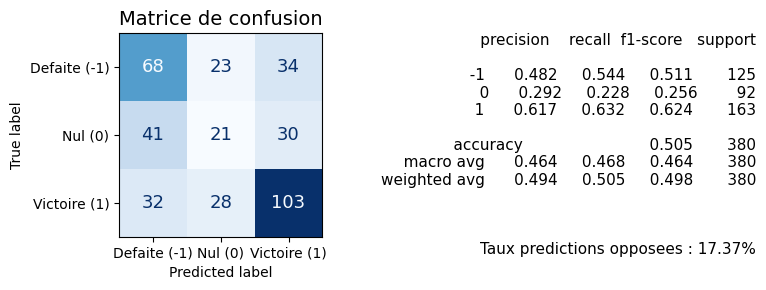

In [86]:
svm_model = SVC(kernel="rbf",class_weight="balanced",gamma="scale",C=0.1)
svm_model.fit(X_2013_2021, Y_2013_2021)
y_svm_prediction_validation_1 = svm_model.predict(X_2022)
modele.affichage_complet_score(Y_2022,y_svm_prediction_validation_1)

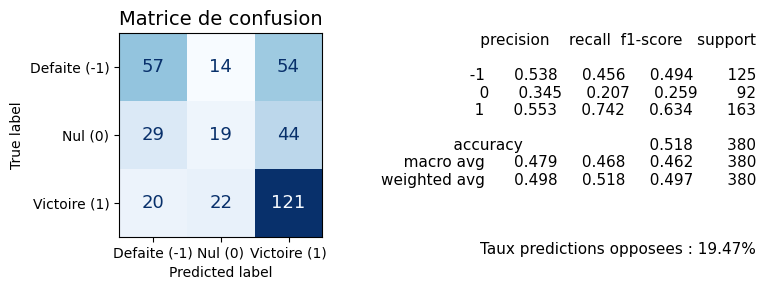

In [87]:
from sklearn.ensemble import RandomForestRegressor

reg_forest = RandomForestRegressor(
    n_estimators=1000,
    min_samples_split=0.09,  #Utiliser du % c’est mieux pour généraliser
    min_samples_leaf=0.006,
    max_features='sqrt',
    oob_score=True,
    random_state=1,
    n_jobs=-1)

reg_forest.fit(X_2013_2021, Y_2013_2021)
y_pred_forest = reg_forest.predict(X_2022)

# Seuils identiques
y_pred_rf = np.where(y_pred_forest < -0.1, -1, np.where(y_pred_forest > 0.1, 1, 0))

modele.affichage_complet_score(Y_2022, y_pred_rf)

TEST DIFFÉRENT DATA SET

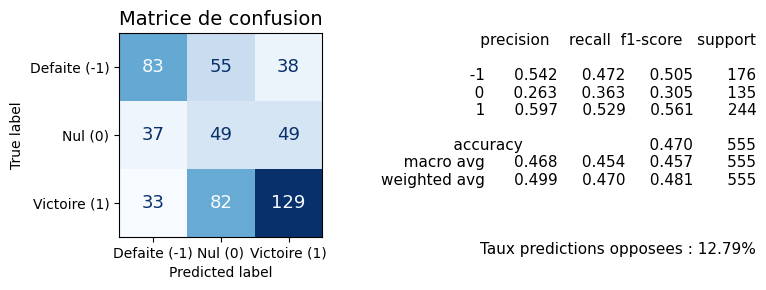

In [97]:
# RÉFÉRENCE :
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Création du pipeline : standardisation + SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),        # Étape 1 : standardisation
    ('svm', SVC(kernel="rbf", class_weight="balanced", gamma="scale", C=0.1))  # Étape 2 : SVM
])

# Entraînement sur les données d'entraînement
svm_pipeline.fit(X_train_sans_2012, Y_train_sans_2012)

# Prédiction sur les données de validation
y_svm_prediction_validation_1 = svm_pipeline.predict(X_validation_sans_2012)

# Évaluation avec ta fonction personnalisée
modele.affichage_complet_score(Y_validation_sans_2012, y_svm_prediction_validation_1)


In [ ]:
X_train_avec_2012, X_temp_avec_2012, Y_train_avec_2012, Y_temp_avec_2012 = train_test_split(X, Y, test_size=0.3, random_state=42)
X_validation_avec_2012, X_test_avec_2012, Y_validation_avec_2012, Y_test_avec_2012 = train_test_split(X_temp_avec_2012, Y_temp_avec_2012, test_size=0.5, random_state=42)

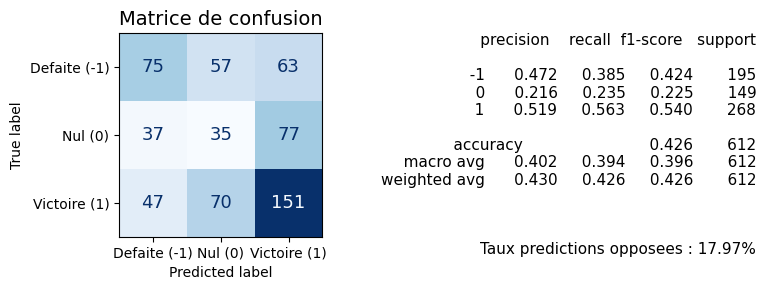

In [93]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Création du pipeline : standardisation + SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),        # Étape 1 : standardisation
    ('svm', SVC(kernel="rbf", class_weight="balanced", gamma="scale", C=0.1))  # Étape 2 : SVM
])

# Entraînement sur les données d'entraînement
svm_pipeline.fit(X_train_avec_2012, Y_train_avec_2012)

# Prédiction sur les données de validation
y_svm_prediction_validation_1 = svm_pipeline.predict(X_validation_avec_2012)

# Évaluation avec ta fonction personnalisée
modele.affichage_complet_score(Y_validation_avec_2012, y_svm_prediction_validation_1)


In [95]:
df = pd.read_csv("../data/preparee/dataframe_traite_sans_2012_13_14.csv")
X_12_13_14 = df.drop(columns=["game_id","home_club_name","away_club_name","date","season","home_club_id","away_club_id","results","difference classement","home_club_position","away_club_position"]) 
Y_12_13_14 = df["results"]

X_train_12_13_14, X_temp_12_13_14, Y_train_12_13_14, Y_temp_12_13_14 = train_test_split(X_12_13_14, Y_12_13_14, test_size=0.3, random_state=42)
X_validation_12_13_14, X_test_12_13_14, Y_validation_12_13_14, Y_test_12_13_14 = train_test_split(X_temp_12_13_14, Y_temp_12_13_14, test_size=0.5, random_state=42)

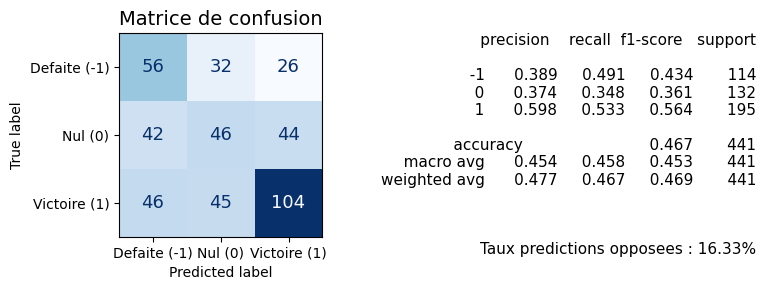

In [96]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Création du pipeline : standardisation + SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),        # Étape 1 : standardisation
    ('svm', SVC(kernel="rbf", class_weight="balanced", gamma="scale", C=0.1))  # Étape 2 : SVM
])

# Entraînement sur les données d'entraînement
svm_pipeline.fit(X_train_12_13_14, Y_train_12_13_14)

# Prédiction sur les données de validation
y_svm_prediction_validation_1 = svm_pipeline.predict(X_validation_12_13_14)

# Évaluation avec ta fonction personnalisée
modele.affichage_complet_score(Y_validation_12_13_14, y_svm_prediction_validation_1)


In [98]:
df = pd.read_csv("../data/preparee/dataframe_traite_nettoye_1.csv")
X_1 = df.drop(columns=["game_id","home_club_name","away_club_name","date","season","home_club_id","away_club_id","results","difference classement","home_club_position","away_club_position"]) 
Y_1 = df["results"]

X_train_1, X_temp_1, Y_train_1, Y_temp_1 = train_test_split(X_1, Y_1, test_size=0.3, random_state=42)
X_validation_1, X_test_1, Y_validation_1, Y_test_1 = train_test_split(X_temp_1, Y_temp_1, test_size=0.5, random_state=42)

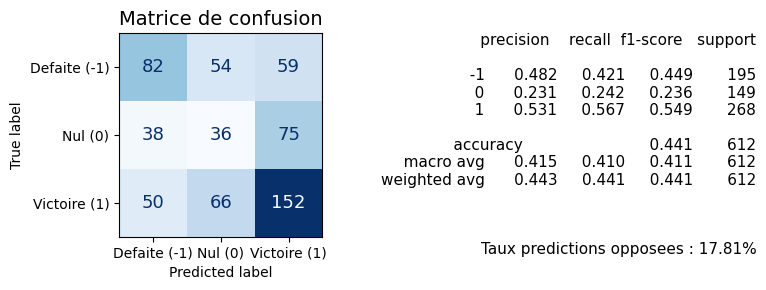

In [99]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Création du pipeline : standardisation + SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),        # Étape 1 : standardisation
    ('svm', SVC(kernel="rbf", class_weight="balanced", gamma="scale", C=0.1))  # Étape 2 : SVM
])

# Entraînement sur les données d'entraînement
svm_pipeline.fit(X_train_1, Y_train_1)

# Prédiction sur les données de validation
y_svm_prediction_validation_1 = svm_pipeline.predict(X_validation_1)

# Évaluation avec ta fonction personnalisée
modele.affichage_complet_score(Y_validation_1, y_svm_prediction_validation_1)


In [100]:
df_2 = pd.read_csv("../data/preparee/dataframe_traite_nettoye_1.csv")
df_2 = df_2[df_2["season"]!=2012]
X_2 = df_2.drop(columns=["game_id","home_club_name","away_club_name","date","season","home_club_id","away_club_id","results","difference classement","home_club_position","away_club_position"]) 
Y_2 = df_2["results"]

X_train_2, X_temp_2, Y_train_2, Y_temp_2 = train_test_split(X_2, Y_2, test_size=0.3, random_state=42)
X_validation_2, X_test_2, Y_validation_2, Y_test_2 = train_test_split(X_temp_2, Y_temp_2, test_size=0.5, random_state=42)

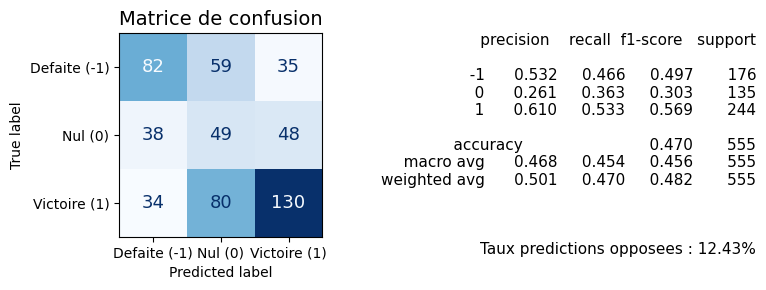

In [101]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Création du pipeline : standardisation + SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),        # Étape 1 : standardisation
    ('svm', SVC(kernel="rbf", class_weight="balanced", gamma="scale", C=0.1))  # Étape 2 : SVM
])

# Entraînement sur les données d'entraînement
svm_pipeline.fit(X_train_2, Y_train_2)

# Prédiction sur les données de validation
y_svm_prediction_validation_2 = svm_pipeline.predict(X_validation_2)

# Évaluation avec ta fonction personnalisée
modele.affichage_complet_score(Y_validation_2, y_svm_prediction_validation_2)
